# 08 · Out-of-Time Evaluation

The four models meet OOT data **for the first time** — no earlier step used weeks 51–91:
- **OOT1 (weeks 51–62):** risk deterioration, bad rate climbing from ~3.7% to > 5%
- **OOT2 (weeks 63–91):** post-COVID population shift; bad rate back to ~2.3%; tax data now from vendor b

Evaluated: discrimination, weekly Gini, the competition stability metric, score drift (PSI), calibration,
scorecard characteristic stability (CSI), and the GBDT advantage over the scorecard.

**Scorecard A vs B rule (fixed before seeing OOT results):** the higher competition stability metric over weeks
51–91 wins; if the difference is < 0.005, the version with the lower OOT score PSI wins.

**Consistency check:** train / valid AUCs here must match `07_dev_comparison.csv`.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().resolve()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
sys.path.insert(0, str(ROOT / "src"))

import gc
import json
import time

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import xgboost as xgb

from hcrisk.config import BOUNDS, PERIODS, PERIOD_LABEL, RES_DIR, savefig
from hcrisk.features import to_model_frame
from hcrisk.metrics import ks_score, metrics, psi_by_deciles, stability_metric, weekly_gini
from hcrisk.scorecard import load_scorecard, score_to_pd, scorecard_score, woe_transform

META = json.loads((RES_DIR / "07_gbdt_meta.json").read_text())
LGB_M = lgb.Booster(model_file=str(RES_DIR / "07_lgb.txt"))
XGB_M = xgb.Booster(); XGB_M.load_model(str(RES_DIR / "07_xgb.json"))
BP, SC_A = load_scorecard("A")
_, SC_B = load_scorecard("B")
SC = {"A": SC_A, "B": SC_B}
SC_FEATS = sorted(set(SC_A["features"]) | set(SC_B["features"]))
SC_CAT = set(SC_A["categorical"]) | set(SC_B["categorical"])
NEED = sorted(set(META["features"]) | set(SC_FEATS))
MODELS = ["Scorecard A", "Scorecard B", "LightGBM", "XGBoost"]
print(f"GBDT features {len(META['features'])} ({META['config']}) | scorecard A {len(SC_A['features'])}, B {len(SC_B['features'])}")

GBDT features 166 (3_merged_nodistrict + R3) | scorecard A 18, B 17


## 1. Score every application
Four batches (one per period) to limit memory. The same categorical encoding as notebook 07 and the same binning as
notebook 06 are applied. Predictions are saved for the strategy notebooks.

In [2]:
DATA = pl.scan_parquet(RES_DIR / "model_data.parquet")
parts, t0 = [], time.time()
for per in PERIODS:
    d = DATA.filter(pl.col("period") == per).select(["case_id", "WEEK_NUM", "target"] + NEED).collect()
    out = {"case_id": d["case_id"].to_numpy(), "WEEK_NUM": d["WEEK_NUM"].to_numpy(), "target": d["target"].to_numpy(),
           "period": [per] * d.height}
    Xg = to_model_frame(d, META["features"], META["categorical"], META["categories"], META["merged_other"])
    out["p_lgb"] = LGB_M.predict(Xg)
    out["p_xgb"] = XGB_M.predict(xgb.DMatrix(Xg, enable_categorical=True), iteration_range=(0, META["xgb_best_iteration"]))
    del Xg; _ = gc.collect()
    sc_df = d.select(SC_FEATS).with_columns(pl.col(pl.Boolean).cast(pl.Float32)).to_pandas()
    for t, m in SC.items():
        out[f"score_{t}"] = scorecard_score(BP, m, sc_df)
    for f in SC_FEATS:                               # WOE per feature, kept for the CSI analysis
        out[f"woe__{f}"] = woe_transform(BP, f, sc_df[f].to_numpy(), f in SC_CAT).astype("float32")
    parts.append(pl.DataFrame(out))
    del d, sc_df; _ = gc.collect()
    print(f"{per:8s} {parts[-1].height:>9,} rows scored  ({time.time() - t0:.0f}s)")

P = pl.concat(parts); del parts; _ = gc.collect()
P = P.with_columns([pl.Series(f"pd_{t}", score_to_pd(P[f"score_{t}"].to_numpy(), SC[t]["scaling"])) for t in SC])
RISK = {"Scorecard A": -P["score_A"].to_numpy(), "Scorecard B": -P["score_B"].to_numpy(),
        "LightGBM": P["p_lgb"].to_numpy(), "XGBoost": P["p_xgb"].to_numpy()}        # all: higher = riskier
PD = {"Scorecard A": P["pd_A"].to_numpy(), "Scorecard B": P["pd_B"].to_numpy(),
      "LightGBM": P["p_lgb"].to_numpy(), "XGBoost": P["p_xgb"].to_numpy()}
Y, WK, PER = P["target"].to_numpy(), P["WEEK_NUM"].to_numpy(), P["period"].to_numpy()
P.select(["case_id", "WEEK_NUM", "period", "target", "score_A", "score_B", "pd_A", "pd_B", "p_lgb", "p_xgb"]) \
 .write_parquet(RES_DIR / "08_predictions.parquet")

1_train    778,703 rows scored  (57s)


2_valid    251,298 rows scored  (77s)


3_oot1     237,744 rows scored  (94s)


4_oot2     258,914 rows scored  (112s)


## 2. Discrimination by period

In [3]:
disc = pl.DataFrame([{"model": m, "period": per, **metrics(Y[PER == per], RISK[m][PER == per])} for m in MODELS for per in PERIODS])
for k in ("AUC", "KS"):
    display(disc.pivot(on="period", index="model", values=k).with_columns(pl.lit(k).alias("metric")))

model,1_train,2_valid,3_oot1,4_oot2,metric
str,f64,f64,f64,f64,str
"""Scorecard A""",0.7881,0.7888,0.7817,0.8151,"""AUC"""
"""Scorecard B""",0.7864,0.7819,0.7751,0.8039,"""AUC"""
"""LightGBM""",0.8582,0.828,0.8218,0.8421,"""AUC"""
"""XGBoost""",0.8644,0.8287,0.8223,0.8426,"""AUC"""


model,1_train,2_valid,3_oot1,4_oot2,metric
str,f64,f64,f64,f64,str
"""Scorecard A""",0.4394,0.4365,0.4291,0.4898,"""KS"""
"""Scorecard B""",0.4359,0.4238,0.4117,0.4655,"""KS"""
"""LightGBM""",0.5541,0.501,0.4897,0.5269,"""KS"""
"""XGBoost""",0.5647,0.5024,0.49,0.5311,"""KS"""


## 3. Weekly Gini over all 92 weeks
Weekly volumes in weeks ~64–70 are small in the full data, so part of the week-to-week noise there is sampling noise.

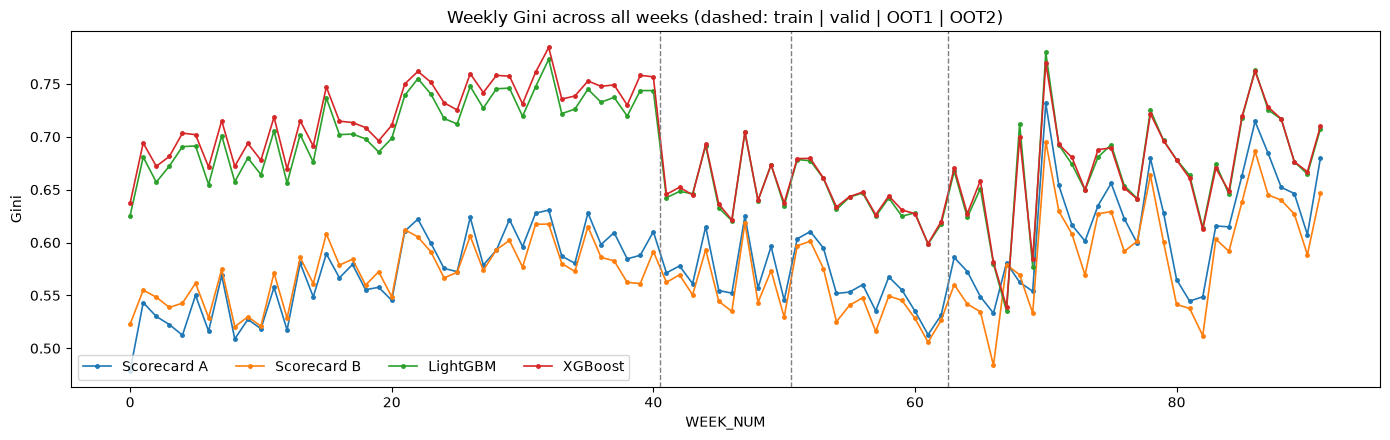

In [4]:
WG = {m: weekly_gini(WK, Y, RISK[m]) for m in MODELS}
fig, ax = plt.subplots(figsize=(14, 4.5))
for m in MODELS:
    ax.plot(WG[m].index, WG[m].values, marker="o", ms=2.5, lw=1.2, label=m)
for x in BOUNDS:
    ax.axvline(x, color="grey", ls="--", lw=1)
ax.set_xlabel("WEEK_NUM"); ax.set_ylabel("Gini"); ax.set_title("Weekly Gini across all weeks (dashed: train | valid | OOT1 | OOT2)")
ax.legend(ncol=4, loc="lower left"); plt.tight_layout(); savefig(fig, "08_weekly_gini_all"); plt.show()

## 4. Competition stability metric
`mean(gini) + 88 · min(0, slope) − 0.5 · std(residuals)` over the weekly Gini series. Only a **negative** slope is
penalised, and heavily (×88). Decision column: **OOT (51–91)**.

In [5]:
WINDOWS = {"OOT (51-91)": range(51, 92), "OOT1 (51-62)": range(51, 63), "OOT2 (63-91)": range(63, 92), "all (0-91)": range(0, 92)}
stab = pl.DataFrame([{"model": m, "window": w, **{k: round(v, 5) for k, v in stability_metric(WG[m][WG[m].index.isin(r)]).items()}}
                     for m in MODELS for w, r in WINDOWS.items()])
display(stab.pivot(on="window", index="model", values="score"))
display(stab.filter(pl.col("window") == "OOT (51-91)").drop("window"))

model,OOT (51-91),OOT1 (51-62),OOT2 (63-91),all (0-91)
str,f64,f64,f64,f64
"""Scorecard A""",0.57825,-0.08044,0.59395,0.56455
"""Scorecard B""",0.55976,-0.03785,0.57284,0.55581
"""LightGBM""",0.64064,0.12178,0.64791,0.62425
"""XGBoost""",0.64214,0.12781,0.64927,0.61259


model,score,gini_mean,slope,res_std
str,f64,f64,f64,f64
"""Scorecard A""",0.57825,0.60025,0.00257,0.04401
"""Scorecard B""",0.55976,0.58132,0.00228,0.04314
"""LightGBM""",0.64064,0.6623,0.00174,0.04332
"""XGBoost""",0.64214,0.66301,0.00168,0.04173


## 5. Score drift (PSI against train deciles)

In [6]:
psi_tab = pl.DataFrame([{"model": m, **{per: round(psi_by_deciles(RISK[m][PER == "1_train"], RISK[m][PER == per]), 4)
                                        for per in PERIODS[1:]}} for m in MODELS])
display(psi_tab)

model,2_valid,3_oot1,4_oot2
str,f64,f64,f64
"""Scorecard A""",0.0343,0.0413,0.145
"""Scorecard B""",0.0095,0.0085,0.0879
"""LightGBM""",0.0098,0.0135,0.0695
"""XGBoost""",0.0097,0.0112,0.0583


## 6. Scorecard A or B — apply the pre-registered rule

In [7]:
get = lambda m: stab.filter((pl.col("model") == m) & (pl.col("window") == "OOT (51-91)"))["score"][0]
sA, sB = get("Scorecard A"), get("Scorecard B")
psiA = float(np.mean([psi_tab.filter(pl.col("model") == "Scorecard A")[p][0] for p in ("3_oot1", "4_oot2")]))
psiB = float(np.mean([psi_tab.filter(pl.col("model") == "Scorecard B")[p][0] for p in ("3_oot1", "4_oot2")]))
if abs(sA - sB) >= 0.005:
    CHOSEN_SC, why = ("A" if sA > sB else "B"), f"OOT stability metric A = {sA:.4f}, B = {sB:.4f} (difference >= 0.005)"
else:
    CHOSEN_SC, why = ("A" if psiA <= psiB else "B"), f"stability metrics within 0.005; lower OOT score PSI (A = {psiA:.4f}, B = {psiB:.4f})"
print(f"chosen scorecard: {CHOSEN_SC} — {why}")

chosen scorecard: A — OOT stability metric A = 0.5783, B = 0.5598 (difference >= 0.005)


## 7. Calibration
`actual / predicted` > 1 means risk is under-estimated. Decile curves use train deciles of the predicted PD;
points above the diagonal are under-estimated.

model,1_train,2_valid,3_oot1,4_oot2
str,f64,f64,f64,f64
"""Scorecard A""",1.015,1.369,1.479,0.953
"""Scorecard B""",0.993,1.353,1.474,1.003
"""LightGBM""",1.0,1.277,1.457,1.052
"""XGBoost""",1.0,1.236,1.414,1.038


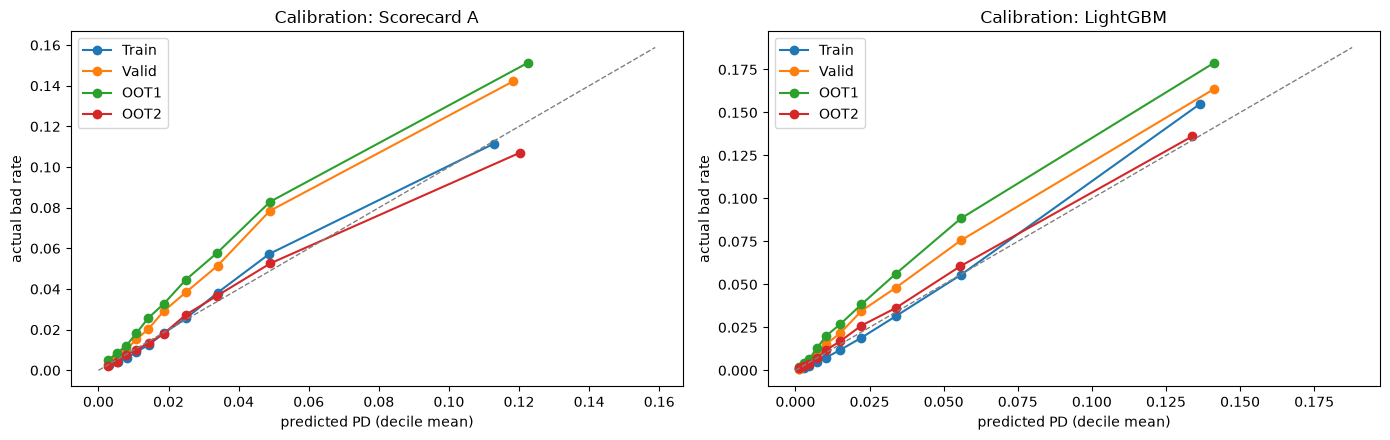

In [8]:
calib = pl.DataFrame([{"model": m, "period": per, "pred_PD": float(PD[m][PER == per].mean()), "actual": float(Y[PER == per].mean()),
                       "actual/pred": round(float(Y[PER == per].mean() / PD[m][PER == per].mean()), 3)} for m in MODELS for per in PERIODS])
display(calib.pivot(on="period", index="model", values="actual/pred"))
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, m in zip(axes, [f"Scorecard {CHOSEN_SC}", "LightGBM"]):
    edges = np.unique(np.quantile(PD[m][PER == "1_train"], np.linspace(0, 1, 11)[1:-1]))
    for per in PERIODS:
        k = PER == per
        t = pd.DataFrame({"b": np.searchsorted(edges, PD[m][k], side="right"), "p": PD[m][k], "y": Y[k]}).groupby("b").mean()
        ax.plot(t["p"], t["y"], marker="o", label=PERIOD_LABEL[per])
    lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([0, lim], [0, lim], color="grey", ls="--", lw=1)
    ax.set_xlabel("predicted PD (decile mean)"); ax.set_ylabel("actual bad rate"); ax.set_title(f"Calibration: {m}"); ax.legend()
plt.tight_layout(); savefig(fig, "08_calibration"); plt.show()

**Full-data reading:** OOT1 under-estimates risk by ~45% — the deterioration is macro-driven and invisible in
applicant features. In OOT2 calibration roughly recovers: approved applicants genuinely look safer in their features
(e.g. higher tax amounts), and the models pick that up. *Population shifts are visible to the model; macro shifts are not.*

## 8. Characteristic stability (CSI) of the chosen scorecard
Same formula as PSI, applied to each feature's optimal-bin distribution — it pinpoints which features drive score drift.

In [9]:
rows = []
for f in SC[CHOSEN_SC]["features"]:
    w = P[f"woe__{f}"].to_numpy()
    base = pd.Series(w[PER == "1_train"]).value_counts(normalize=True)
    r = {"feature": f}
    for per in PERIODS[1:]:
        cur = pd.Series(w[PER == per]).value_counts(normalize=True)
        idx = base.index.union(cur.index)
        b, c = np.maximum(base.reindex(idx).fillna(0).values, 1e-6), np.maximum(cur.reindex(idx).fillna(0).values, 1e-6)
        r[per] = round(float(((c - b) * np.log(c / b)).sum()), 4)
    rows.append(r)
csi = pl.DataFrame(rows).sort("4_oot2", descending=True)
display(csi)

feature,2_valid,3_oot1,4_oot2
str,f64,f64,f64
"""pmts_overdue_1152A__mean""",0.6176,0.7604,1.0611
"""dpdmaxdateyear_896T_yrsago__me…",0.6198,0.7599,1.0604
"""totalamount_6A__mean""",0.5554,0.6907,1.0022
"""numberofoverdueinstlmaxdat_148…",0.2627,0.3547,0.5184
"""numberofcontrsvalue_358L__max""",0.0451,0.0963,0.2444
…,…,…,…
"""avgdpdtolclosure24_3658938P""",0.0004,0.008,0.0411
"""education_927M__first""",0.0054,0.0003,0.0407
"""mobilephncnt_593L""",0.0001,0.0055,0.0273


## 9. The price of interpretability — LightGBM advantage over the chosen scorecard

In [10]:
auc = disc.pivot(on="period", index="model", values="AUC")
gap = pl.DataFrame([{"period": per, "AUC_scorecard": auc.filter(pl.col("model") == f"Scorecard {CHOSEN_SC}")[per][0],
                     "AUC_LightGBM": auc.filter(pl.col("model") == "LightGBM")[per][0]} for per in PERIODS]).with_columns(
    (pl.col("AUC_LightGBM") - pl.col("AUC_scorecard")).round(4).alias("LightGBM_advantage"))
display(gap)

disc.write_csv(RES_DIR / "08_discrimination.csv", include_bom=True)
stab.write_csv(RES_DIR / "08_stability_metric.csv", include_bom=True)
psi_tab.write_csv(RES_DIR / "08_score_psi.csv", include_bom=True)
calib.write_csv(RES_DIR / "08_calibration.csv", include_bom=True)
csi.write_csv(RES_DIR / "08_csi_scorecard.csv", include_bom=True)
pd.DataFrame(WG).to_csv(RES_DIR / "08_weekly_gini.csv", encoding="utf-8-sig")
(RES_DIR / "08_decision.json").write_text(json.dumps({"chosen_scorecard": CHOSEN_SC, "reason": why,
                                                      "stability_oot": {"A": sA, "B": sB}, "psi_oot": {"A": psiA, "B": psiB}}, indent=1))
print("saved: 08_predictions.parquet, 08_*.csv, 08_decision.json")

period,AUC_scorecard,AUC_LightGBM,LightGBM_advantage
str,f64,f64,f64
"""1_train""",0.7881,0.8582,0.0701
"""2_valid""",0.7888,0.828,0.0392
"""3_oot1""",0.7817,0.8218,0.0401
"""4_oot2""",0.8151,0.8421,0.027


saved: 08_predictions.parquet, 08_*.csv, 08_decision.json
